In [3]:
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt
import time

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Job Title  60 non-null     object
 1   Company    60 non-null     object
 2   Location   60 non-null     object
dtypes: object(3)
memory usage: 1.5+ KB


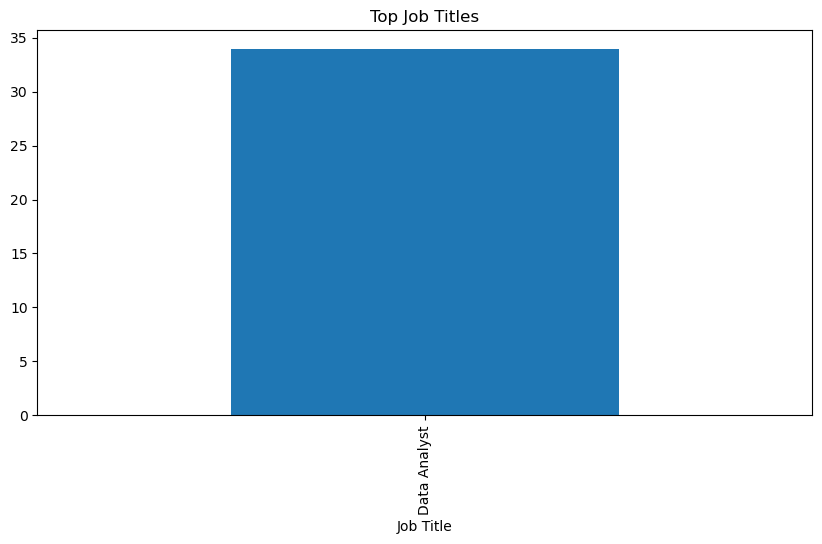

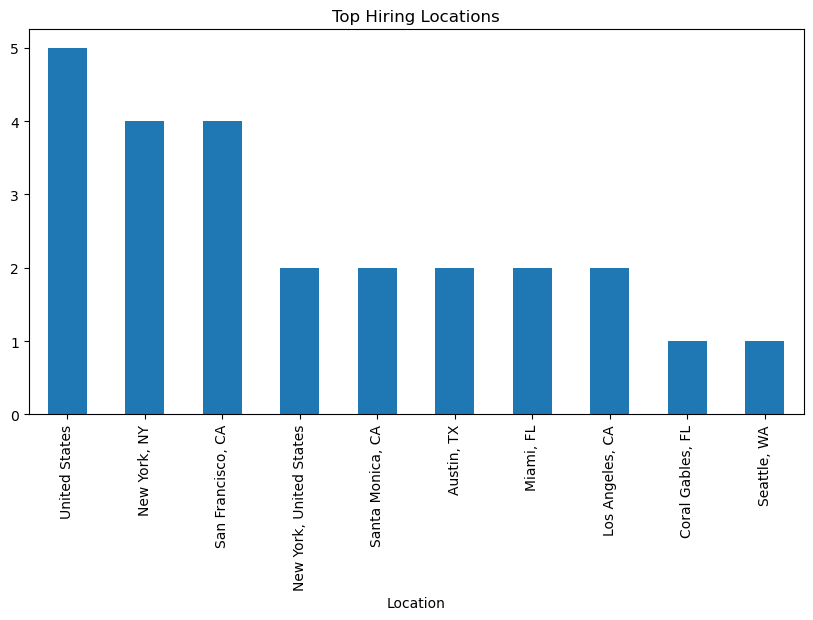

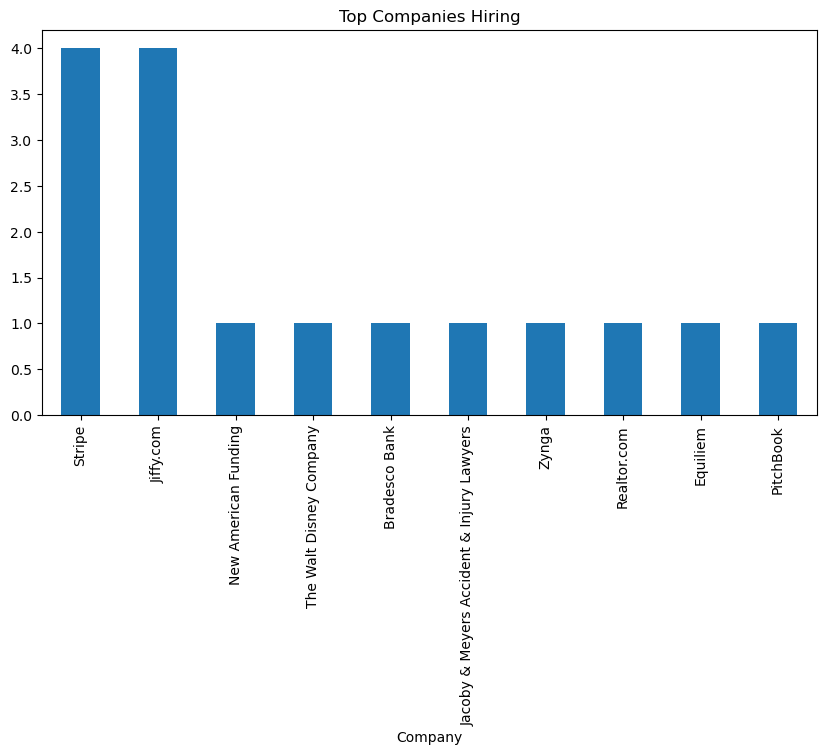

In [9]:
# url = "https://www.linkedin.com/jobs/search?keywords=data%20analyst"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36',
    
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7',
    'Accept-Language': 'en-US,en;q=0.9',
    'Referer': 'https://www.google.com',
    'DNT': '1',
    'Connection': 'keep-alive',
    'Upgrade-Insecure-Requests': '1'
}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")


jobs = soup.find_all("div", class_="base-card")

job_title = []
company = []
location = []

for job in jobs:
    title = job.find("h3")
    company_name = job.find("h4")
    job_location = job.find("span", class_="job-search-card__location")

    job_title.append(title.text.strip() if title else None)
    company.append(company_name.text.strip() if company_name else None)
    location.append(job_location.text.strip() if job_location else None)

    ###  DataFrame

    df = pd.DataFrame({
    "Job Title": job_title,
    "Company": company,
    "Location": location
})

df.head()

#### datacleaning
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

### Dataset Overview
df.info()
df.describe(include='object')

### Top Job Titles
df['Job Title'].value_counts().head(10)
df = df[df['Job Title'] == "Data Analyst"]


## Visualization:
plt.figure(figsize=(10,5))
df['Job Title'].value_counts().head(10).plot(kind='bar')
plt.title("Top Job Titles")
plt.show()


### Top Hiring Locations
plt.figure(figsize=(10,5))
df['Location'].value_counts().head(10).plot(kind='bar')
plt.title("Top Hiring Locations")
plt.show()

#### Company-wise Job Count
plt.figure(figsize=(10,5))
df['Company'].value_counts().head(10).plot(kind='bar')
plt.title("Top Companies Hiring")
plt.show()

## Save Dataset
df.to_csv("linkedin_jobs_data.csv", index=False)

In [6]:
### Top Job Titles
df['Job Title'].value_counts().head(10)
df = df[df['Job Title'] == "Data Analyst"]

In [8]:
df

,Job Title,Company,Location
1,Data Analyst,The Walt Disney Company,"Santa Monica, CA"
2,Data Analyst,Stripe,"New York, United States"
3,Data Analyst,Stripe,United States
4,Data Analyst,Stripe,"San Francisco, CA"
5,Data Analyst,Stripe,"Seattle, WA"
6,Data Analyst,New American Funding,"Tustin, CA"
9,Data Analyst,Bradesco Bank,"Coral Gables, FL"
10,Data Analyst,Jacoby & Meyers Accident & Injury Lawyers,"Los Angeles, CA"
11,Data Analyst,Jiffy.com,"San Francisco, CA"
14,Data Analyst,Zynga,"Austin, TX"


In [10]:
### checking for missing values
df.isna().sum()

Job Title    0
Company      0
Location     0
dtype: int64

In [11]:
### checking for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
### drop the duplicates
df.drop_duplicates(inplace = True)

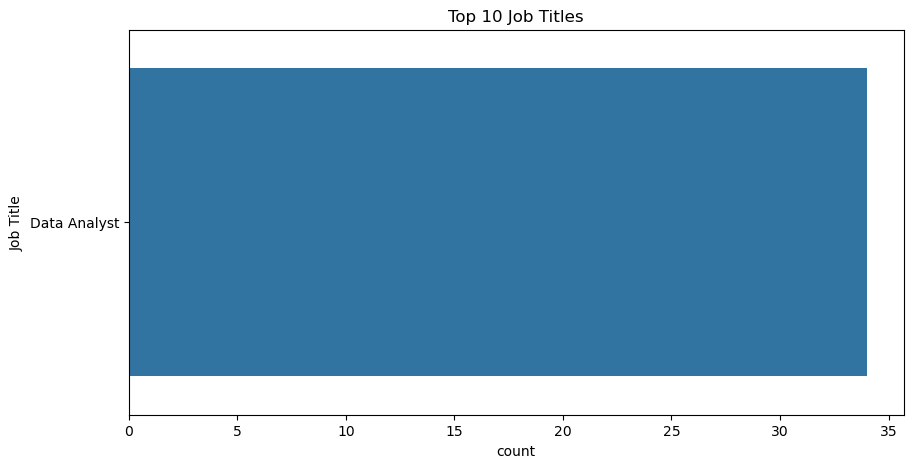

In [15]:
### Univariate Analysis

##### Job Title Distribution
df['Job Title'].value_counts().head(10)

#### Plot:
plt.figure(figsize=(10,5))
sns.countplot(y=df['Job Title'], order=df['Job Title'].value_counts().head(10).index)
plt.title("Top 10 Job Titles")
plt.show()

In [16]:
### Location Frequency
df['Location'].value_counts()


Location
United States               5
New York, NY                4
San Francisco, CA           4
New York, United States     2
Santa Monica, CA            2
Austin, TX                  2
Miami, FL                   2
Los Angeles, CA             2
Coral Gables, FL            1
Seattle, WA                 1
Tustin, CA                  1
Dallas, TX                  1
Irvine, CA                  1
Pasadena, CA                1
Tampa, FL                   1
Denver Metropolitan Area    1
Orlando, FL                 1
Atlanta, GA                 1
Washington, DC              1
Name: count, dtype: int64

# Insight:
Shows which cities have the highest number of job openings.

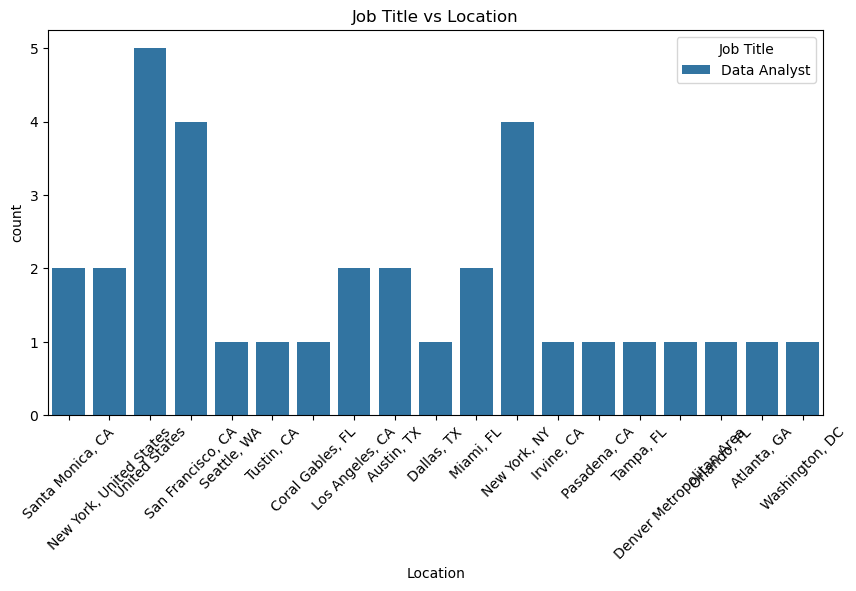

In [17]:
### Bivariate Analysis
#######Job Title vs Location
pd.crosstab(df['Job Title'], df['Location']).head()
### Plot
top_titles = df['Job Title'].value_counts().head(5).index
filtered_df = df[df['Job Title'].isin(top_titles)]

plt.figure(figsize=(10,5))
sns.countplot(data=filtered_df, x='Location', hue='Job Title')
plt.title("Job Title vs Location")
plt.xticks(rotation=45)
plt.show()

# Insight:
Certain job roles are concentrated in specific cities.

In [18]:
### 2: Company vs Job Count

df.groupby('Company').size().sort_values(ascending=False).head(10)
########------------Shows which companies are hiring the most.-----------------------------



Company
Stripe            4
Jiffy.com         4
Air Apps          1
Baseten           1
East West Bank    1
Equativ           1
Equiliem          1
FlowerHire        1
Gemean            1
Good Apple        1
dtype: int64

In [19]:
### Multivariate Analysis
######### 1: Job Title + Location + Company
df.groupby(['Job Title', 'Location', 'Company']).size().reset_index(name='Job Count').head()


,Job Title,Location,Company,Job Count
0,Data Analyst,"Atlanta, GA",Robert Half,1
1,Data Analyst,"Austin, TX",Realtor.com,1
2,Data Analyst,"Austin, TX",Zynga,1
3,Data Analyst,"Coral Gables, FL",Bradesco Bank,1
4,Data Analyst,"Dallas, TX",Jiffy.com,1


# Insight:
Identifies which companies hire specific roles in specific locations.

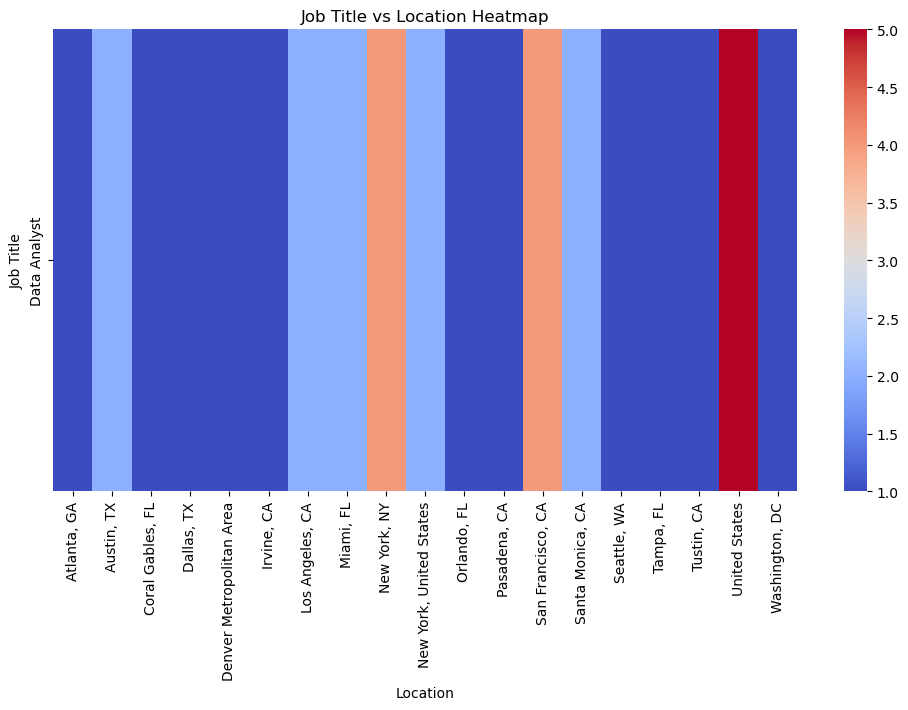

In [20]:
### 2: Heatmap (Job Title vs Location)
pivot_table = pd.pivot_table(
    df,
    values='Company',
    index='Job Title',
    columns='Location',
    aggfunc='count'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot_table.fillna(0), cmap='coolwarm')
plt.title("Job Title vs Location Heatmap")
plt.show()
